In [238]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import logging
from one.api import ONE
from brainbox.io.one import SessionLoader
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from collections import defaultdict
import pandas as pd
from manifold.decoding.functions.utils import check_config_decoding
import numpy as np
import pickle as pkl
from manifold.decoding.functions import nulldistributions
from communication_subspace.ibl_communication.utils import load_widefield_epoch
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
import warnings
from matplotlib import pyplot as plt
warnings.filterwarnings("ignore")
from manifold.utils import get_trial_masks
from glob import glob
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
import statsmodels.stats.multitest as smm
import seaborn as sns

In [2]:
%load_ext autoreload 
%autoreload 2

In [207]:
files = glob('../data/generated/wifi/ppis/*.pkl')

In [216]:
# build combined df
df = []
for idx,f in enumerate(files):
    data_session = pkl.load(open(f,'rb'))
    data_session['animal-id'] = idx
    df.append(data_session)

In [217]:
combined_df = pd.concat(df)

In [222]:
combined_df['seed'] = combined_df['seed'].str[0]
combined_df['target'] = combined_df['target'].str[0]

In [223]:
grouped = combined_df.groupby(['condition', 'seed', 'target'])

In [224]:
def compute_group_level_ppi(combined_df, min_animals=3):
    results = []
    
    
    grouped = combined_df.groupby(['condition', 'seed', 'target'])
    
    for (condition, seed, target), group_data in grouped:
        
    
        betas = group_data['interaction_beta'].dropna().values
        
        n_animals = len(betas)
        
    
        if n_animals < min_animals:
            continue
            
    
        t_stat, p_val = ttest_1samp(betas, popmean=0)
        mean_beta = np.mean(betas)
        sem_beta = np.std(betas, ddof=1) / np.sqrt(n_animals)
        
        results.append({
            'condition': condition,
            'seed': seed,
            'target': target,
            'mean_beta': mean_beta,
            'sem_beta': sem_beta,
            't_stat': t_stat,
            'p_val_raw': p_val,
            'n_animals': n_animals
        })
        
    results_df = pd.DataFrame(results)
    final_dfs = []
    
    for condition in results_df['condition'].unique():
        cond_df = results_df[results_df['condition'] == condition].copy()
        
        reject, pvals_corrected, _, _ = smm.multipletests(
            cond_df['p_val_raw'], alpha=0.05, method='fdr_bh'
        )
        
        cond_df['p_val_fdr'] = pvals_corrected
        cond_df['is_significant'] = reject
        final_dfs.append(cond_df)
        
    final_results = pd.concat(final_dfs, ignore_index=True)
    final_results = final_results.sort_values(by=['condition', 'p_val_fdr'])
    
    return final_results

In [225]:
population_ppi_results = compute_group_level_ppi(combined_df)

In [272]:
sig_results

,condition,seed,target,mean_beta,sem_beta,t_stat,p_val_raw,n_animals,p_val_fdr,is_significant
57,congruence,MOB,PL,0.033790,0.008559,3.947676,0.000340,38,0.114926,True
286,congruence,SSp-m,AUDd,0.033676,0.007824,4.303961,0.000287,23,0.114926,True
56,congruence,MOB,MOs,0.244133,0.073904,3.303378,0.002088,39,0.124429,True
60,congruence,MOB,RSPv,0.068306,0.020805,3.283080,0.002209,39,0.124429,True
106,congruence,MOs,MOB,0.007023,0.002026,3.466528,0.001298,40,0.124429,True
...,...,...,...,...,...,...,...,...,...,...
558,congruence,VISl,SSp-n,0.000000,0.028950,-0.032819,0.974023,33,0.979820,False
564,congruence,VISl,VISa,0.000000,0.043274,-0.030662,0.975729,33,0.980079,False
555,congruence,VISl,SSp-bfd,0.000000,0.063088,0.019104,0.984876,33,0.987799,False
497,congruence,VISal,MOp,0.000000,0.057704,-0.005075,0.995981,34,0.997035,False


In [247]:
sig_results = population_ppi_results[population_ppi_results['condition'] == 'congruence']
sig_results.loc[~sig_results['is_significant'], 'mean_beta'] = 0

In [248]:
matrix = sig_results.pivot(index='seed', columns='target', values='mean_beta')

<Axes: xlabel='target', ylabel='seed'>

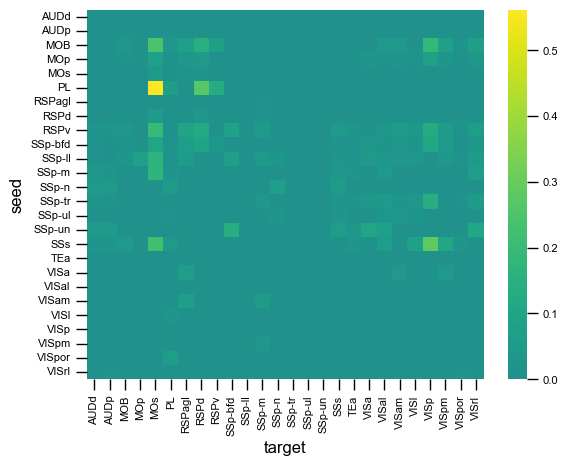

In [249]:
sns.heatmap(matrix, cmap='viridis', center=0)

In [273]:
# get MOS, PL
from manifold.widefield_ppi import return_labels


session_id = sessions_all[0]
one = ONE(mode="local")
ssl = SessionLoader(one, sessions_all[0])
ssl.load_trials(collection="alf")
trials = ssl.trials.copy()
config = check_config_decoding()
out = np.nan_to_num(trials.contrastLeft) - np.nan_to_num(trials.contrastRight)
trials["signcont"] = out
trials["stim_side"] = np.sign(trials["signcont"])

_, stimulus_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=False,
        exclude_unbiased=False,
    )
stimulus_non_zero_mask = trials["signcont"] != 0
stim_mask = stimulus_behavioral_mask & stimulus_non_zero_mask
_, choice_behavioral_mask = load_trials_and_mask(
        one,
        session_id,
        exclude_nochoice=True,
        exclude_unbiased=False,
    )
choice_mask = choice_behavioral_mask
combined_mask = choice_mask & stim_mask

stim_data, stim_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="stim", regions=[["PL"]])
choice_data, choice_region_names = load_widefield_epoch(one, session_id, trials, config["hemisphere"], epoch="choice", response_time=True, regions=[["MOs"]])

# stim is frame2 - frame1
# choice is frame2
session_results = []
terms = "congruence"
labels, conditions = return_labels(trials, terms)
final_mask = combined_mask & conditions
labels_masked = labels[final_mask]

In [274]:
from manifold.widefield_ppi import compute_ppi_interaction


stim_frame = stim_data[0][:, final_mask, :]
stim_frame = stim_frame[1,:] - stim_frame[0,:] # do the delta 
choice_frame = choice_data[0][:, final_mask, :]
choice_frame = choice_frame[1,:]
results = compute_ppi_interaction(Y=choice_frame, X=stim_frame, labels=labels_masked, reduction="PCA")

In [275]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
stim_pca = pca.fit_transform(stim_frame).squeeze()
choice_pca = pca.fit_transform(choice_frame).squeeze()

In [276]:
labels_masked.shape

(590,)

In [279]:

plot_df = pd.DataFrame({
    'PL': stim_pca,
    'MOs': choice_pca,
    'Condition': ['Congruent' if c == 1 else 'Incongruent' for c in labels_masked]
})

<Figure size 600x500 with 0 Axes>

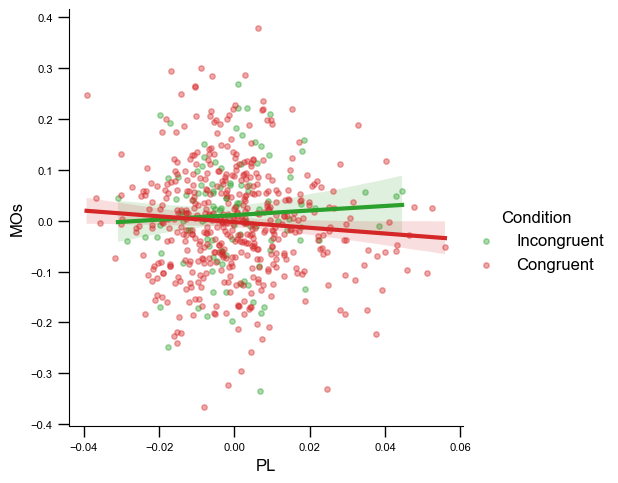

In [281]:
plt.figure(figsize=(6, 5))
sns.lmplot(
    data=plot_df,
    x='PL',
    y='MOs',
    hue='Condition',
    palette=['#2ca02c', '#d62728'],
    scatter_kws={'alpha': 0.4, 's': 15},
    line_kws={'linewidth': 3}
)
